# Scaling Plot

Load the latest scaling CSV and plot sampling, training, and inference runtime plus random-walk matrix storage size.


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path("results")
csv_candidates = sorted(RESULTS_DIR.glob("scaling_*.csv"))
if not csv_candidates:
    raise FileNotFoundError(f"No scaling results found in {RESULTS_DIR}")

csv_path = csv_candidates[-1]
df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
df.head()

Loaded: results/scaling_20260329_203816.csv


,n_nodes,n_edges,seed,device,sampling_time_sec,sampling_storage_mb,sampling_total_nnz,training_time_sec,inference_time_sec,noise,modulation_norm
0,64,64,0,cpu,0.146052,0.017128,960,2.186787,0.012908,0.004709,0.298127
1,64,64,1,cpu,0.139075,0.017128,960,1.330368,0.011818,0.007587,0.297215
2,64,64,2,cpu,0.131568,0.017128,960,1.419616,0.011533,0.005421,0.274086
3,128,128,0,cpu,0.296766,0.034218,1920,2.251217,0.021208,0.002696,0.229108
4,128,128,1,cpu,0.230043,0.034218,1920,1.778420,0.017952,0.007319,0.322712


In [6]:
summary = (
    df.groupby("n_nodes")
    .agg(
        sampling_time_sec_mean=("sampling_time_sec", "mean"),
        sampling_time_sec_std=("sampling_time_sec", "std"),
        training_time_sec_mean=("training_time_sec", "mean"),
        training_time_sec_std=("training_time_sec", "std"),
        inference_time_sec_mean=("inference_time_sec", "mean"),
        inference_time_sec_std=("inference_time_sec", "std"),
        sampling_storage_mb_mean=("sampling_storage_mb", "mean"),
        sampling_storage_mb_std=("sampling_storage_mb", "std"),
        sampling_total_nnz_mean=("sampling_total_nnz", "mean"),
    )
    .reset_index()
)
summary


,n_nodes,sampling_time_sec_mean,sampling_time_sec_std,training_time_sec_mean,training_time_sec_std,inference_time_sec_mean,inference_time_sec_std,sampling_storage_mb_mean,sampling_storage_mb_std,sampling_total_nnz_mean
0,64,0.138899,0.007244,1.645590,0.470809,0.012086,0.000726,0.017128,0.0,960.0
1,128,0.269968,0.035245,2.047606,0.243124,0.020188,0.001939,0.034218,0.0,1920.0
2,256,0.452078,0.011123,3.191316,0.435857,0.034981,0.007842,0.068398,0.0,3840.0
3,512,1.027997,0.107287,10.185609,1.629448,0.071223,0.026041,0.136757,0.0,7680.0
4,1024,1.946282,0.026969,17.516486,3.667867,0.187983,0.026429,0.273476,0.0,15360.0


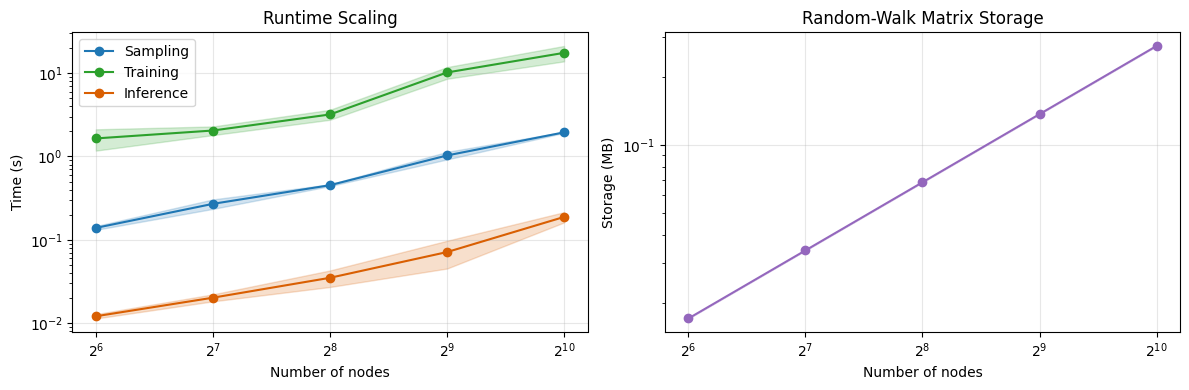

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

time_specs = [
    ("sampling_time_sec", "Sampling", "#1f77b4"),
    ("training_time_sec", "Training", "#2ca02c"),
    ("inference_time_sec", "Inference", "#d95f02"),
]
for prefix, label, color in time_specs:
    axes[0].plot(summary["n_nodes"], summary[f"{prefix}_mean"], marker="o", color=color, label=label)
    axes[0].fill_between(
        summary["n_nodes"],
        summary[f"{prefix}_mean"] - summary[f"{prefix}_std"].fillna(0.0),
        summary[f"{prefix}_mean"] + summary[f"{prefix}_std"].fillna(0.0),
        color=color,
        alpha=0.2,
    )
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("Number of nodes")
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Runtime Scaling")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(summary["n_nodes"], summary["sampling_storage_mb_mean"], marker="o", color="#9467bd")
axes[1].fill_between(
    summary["n_nodes"],
    summary["sampling_storage_mb_mean"] - summary["sampling_storage_mb_std"].fillna(0.0),
    summary["sampling_storage_mb_mean"] + summary["sampling_storage_mb_std"].fillna(0.0),
    color="#9467bd",
    alpha=0.2,
)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("Number of nodes")
axes[1].set_ylabel("Storage (MB)")
axes[1].set_title("Random-Walk Matrix Storage")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
summary[["n_nodes", "sampling_storage_mb_mean", "sampling_total_nnz_mean"]]


,n_nodes,sampling_storage_mb_mean,sampling_total_nnz_mean
0,64,0.017128,960.0
1,128,0.034218,1920.0
2,256,0.068398,3840.0
3,512,0.136757,7680.0
4,1024,0.273476,15360.0
